# HybridTCNTransformer: Dual-Branch TCN-Transformer with Cross-Attention Fusion

## NASA C-MAPSS FD001 - Turbofan Engine Anomaly Detection

### Architecture (Novel Hybrid)

```
Input (B, 30, D)
    │
    ├──→ Multi-Scale TCN (kernel 3,5,7)  ──→ TCN Features
    │         3 parallel branches               │
    │                                            │
    ├──→ Transformer Encoder (8-head)    ──→ TF Features
    │         3 layers, learnable PE             │
    │                                            ▼
    └────────────→ Cross-Attention Fusion (bidirectional)
                              │
                     Feature Attention Gate (SE-style)
                              │
                     Temporal Attention Pooling
                              │
                     Classification Head + Focal Loss
```

### Key Techniques
- **Multi-Scale TCN**: Parallel branches with kernel sizes 3, 5, 7
- **Bidirectional Cross-Attention**: TCN and Transformer learn from each other
- **Gated Fusion**: Learns optimal contribution from each branch
- **Feature Attention Gate**: SE-style channel re-weighting
- **Focal Loss**: Handles class imbalance
- **Mixup Augmentation**: Regularization
- **Engine-based Validation Split**: Prevents data leakage

In [20]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1. Setup & Imports

In [ ]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (
    precision_score, recall_score, f1_score, accuracy_score,
    confusion_matrix, classification_report, roc_auc_score
)
import matplotlib.pyplot as plt
import time
import copy
import warnings
import os
import math

warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")


## 2. Google Colab - Mount Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ============================================================
# UPDATE THIS PATH to your data folder
# ============================================================
BASE = "/content/drive/MyDrive/data"

# Verify data exists
print("Files in data folder:")
for f in sorted(os.listdir(BASE)):
    print(f"  {f}")

Mounted at /content/drive
Files in data folder:
  Damage Propagation Modeling.pdf
  RUL_FD001.txt
  RUL_FD002.txt
  RUL_FD003.txt
  RUL_FD004.txt
  readme.txt
  test_FD001.csv
  test_FD001.txt
  test_FD002.csv
  test_FD002.txt
  test_FD003.csv
  test_FD003.txt
  test_FD004.csv
  test_FD004.txt
  train_FD001.csv
  train_FD001.txt
  train_FD002.csv
  train_FD002.txt
  train_FD003.csv
  train_FD003.txt
  train_FD004.csv
  train_FD004.txt


## 3. Configuration

In [ ]:
CFG = {
    # Data
    'anomaly_ratio': 0.40,    # last 40% of engine life = anomaly (cycle-ratio)
    'sequence_length': 30,
    'stride': 1,
    'val_split': 0.15,

    # Multi-Scale TCN  (2 layers, smaller hidden)
    'tcn_channels': [64, 64],
    'tcn_kernel_sizes': [3, 5, 7],
    'tcn_dropout': 0.25,

    # Transformer  (smaller d_model, fewer layers)
    'd_model': 64,
    'nhead': 4,
    'num_encoder_layers': 2,
    'dim_feedforward': 128,
    'transformer_dropout': 0.25,

    # Fusion
    'fusion_dim': 64,
    'fusion_heads': 2,

    # Classification Head
    'head_hidden': 64,
    'head_dropout': 0.40,

    # Training
    'batch_size': 64,
    'epochs': 150,
    'lr': 3e-4,
    'weight_decay': 5e-4,
    'patience': 25,
    'lr_patience': 10,
    'lr_factor': 0.5,
    'min_lr': 1e-6,
    'grad_clip': 1.0,
    'focal_alpha': 0.60,
    'focal_gamma': 2.0,
    'label_smoothing': 0.10,
    'mixup_alpha': 0.30,
}

print("Configuration:")
for k, v in CFG.items():
    print(f"  {k}: {v}")


## 4. Data Loading & Preprocessing

In [ ]:
def load_cmapss(base_path, fd='FD001'):
    """Load any C-MAPSS FD dataset (FD001-FD004)."""
    columns = ['unit_number', 'time_in_cycles',
               'operational_setting_1', 'operational_setting_2', 'operational_setting_3']
    columns += [f'sensor_measurement_{i}' for i in range(1, 22)]

    train_csv = f"{base_path}/train_{fd}.csv"
    if os.path.exists(train_csv):
        train_df = pd.read_csv(train_csv)
        test_df  = pd.read_csv(f"{base_path}/test_{fd}.csv")
    else:
        extra = ['drop1', 'drop2']
        train_df = pd.read_csv(f"{base_path}/train_{fd}.txt", sep=r'\s+',
                               header=None, names=columns + extra)
        train_df.drop(extra, axis=1, errors='ignore', inplace=True)
        test_df = pd.read_csv(f"{base_path}/test_{fd}.txt", sep=r'\s+',
                              header=None, names=columns + extra)
        test_df.drop(extra, axis=1, errors='ignore', inplace=True)

    rul_series = pd.read_csv(f"{base_path}/RUL_{fd}.txt",
                             sep=r'\s+', header=None).iloc[:, 0]

    # Add RUL to train
    max_c = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    max_c.columns = ['unit_number', 'max_cycle']
    train_df = train_df.merge(max_c, on='unit_number')
    train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']
    train_df.drop('max_cycle', axis=1, inplace=True)

    # Add RUL to test
    test_max = test_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
    test_max.columns = ['unit_number', 'max_cycle']
    rul_map = dict(zip(test_df['unit_number'].unique(), rul_series.values))
    test_max['final_rul'] = test_max['unit_number'].map(rul_map)
    test_df = test_df.merge(test_max, on='unit_number')
    test_df['RUL'] = test_df['final_rul'] + (test_df['max_cycle'] - test_df['time_in_cycles'])
    test_df.drop(['max_cycle', 'final_rul'], axis=1, inplace=True)

    return train_df, test_df


def select_informative_sensors(df, threshold=0.01):
    sensor_cols = [c for c in df.columns if 'sensor_measurement' in c]
    return [c for c in sensor_cols if df[c].std() > threshold]


def add_engineered_features(df, sensor_cols):
    """Rolling stats + diff per engine (first 7 sensors to limit dimensionality)."""
    new_cols = []
    for col in sensor_cols[:7]:
        df[f'{col}_rmean5'] = df.groupby('unit_number')[col].transform(
            lambda x: x.rolling(5, min_periods=1).mean())
        df[f'{col}_rstd5'] = df.groupby('unit_number')[col].transform(
            lambda x: x.rolling(5, min_periods=1).std().fillna(0))
        df[f'{col}_diff'] = df.groupby('unit_number')[col].transform(
            lambda x: x.diff().fillna(0))
        new_cols += [f'{col}_rmean5', f'{col}_rstd5', f'{col}_diff']
    return df, new_cols


def per_engine_normalize(df, feature_cols, clip_val=5.0):
    """
    Z-score normalize each feature WITHIN each engine's own observed window.

    Why: each engine has its own sensor baseline (some run hotter, cooler, etc.).
    Global normalization mixes inter-engine variance with degradation signal.
    Per-engine normalization forces the model to learn temporal deviation patterns
    (how sensors change over an engine's life) instead of absolute values.
    Works for ALL FDs including multi-condition FD002/FD004 without KMeans.
    """
    arr = df[feature_cols].fillna(0).values.copy().astype(np.float32)
    units = df['unit_number'].values
    for uid in np.unique(units):
        mask = units == uid
        chunk = arr[mask]
        mu = chunk.mean(axis=0)
        sg = chunk.std(axis=0)
        sg[sg < 1e-8] = 1.0          # avoid division by zero for constant sensors
        arr[mask] = (chunk - mu) / sg
    return np.clip(arr, -clip_val, clip_val)


def create_sequences_per_engine(data, labels, units, seq_length, stride=1):
    sequences, seq_labels = [], []
    for uid in np.unique(units):
        mask = units == uid
        ud, ul = data[mask], labels[mask]
        for i in range(0, len(ud) - seq_length + 1, stride):
            sequences.append(ud[i:i + seq_length])
            seq_labels.append(ul[i + seq_length - 1])
    return np.array(sequences, dtype=np.float32), np.array(seq_labels, dtype=np.float32)


print("Data loading functions defined.")


In [ ]:
def prepare_data(cfg, fd='FD001'):
    """
    Full pipeline for any C-MAPSS FD dataset.

    Normalization: per-engine z-score (removes inter-engine baseline differences,
    forces model to learn temporal degradation patterns, works for all FDs).
    Labels: cycle-ratio based — last anomaly_ratio% of total engine life = anomaly.
    """
    print(f"\nLoading {fd}...")
    train_df, test_df = load_cmapss(BASE, fd)
    print(f"  Rows  — Train: {len(train_df)}, Test: {len(test_df)}")

    sensor_cols = select_informative_sensors(train_df)
    train_df, extra_cols = add_engineered_features(train_df, sensor_cols)
    test_df,  _          = add_engineered_features(test_df,  sensor_cols)
    feature_cols = sensor_cols + extra_cols
    print(f"  Features — sensors: {len(sensor_cols)}, total: {len(feature_cols)}")

    # Per-engine normalization (handles all FDs uniformly)
    train_scaled = per_engine_normalize(train_df, feature_cols)
    test_scaled  = per_engine_normalize(test_df,  feature_cols)

    # Cycle-ratio labels  (total_life = time_in_cycles + RUL, constant per engine)
    train_tl     = train_df['time_in_cycles'].values + train_df['RUL'].values
    train_labels = (train_df['time_in_cycles'].values / train_tl
                    > (1 - cfg['anomaly_ratio'])).astype(np.float32)

    test_tl      = test_df['time_in_cycles'].values + test_df['RUL'].values
    test_labels  = (test_df['time_in_cycles'].values / test_tl
                    > (1 - cfg['anomaly_ratio'])).astype(np.float32)

    train_units = train_df['unit_number'].values
    test_units  = test_df['unit_number'].values

    X_all, y_all = create_sequences_per_engine(
        train_scaled, train_labels, train_units,
        cfg['sequence_length'], cfg['stride'])
    X_test, y_test = create_sequences_per_engine(
        test_scaled, test_labels, test_units,
        cfg['sequence_length'], cfg['stride'])

    print(f"  Sequences — Train: {X_all.shape} (anomaly {y_all.mean():.3f}), "
          f"Test: {X_test.shape} (anomaly {y_test.mean():.3f})")

    # Engine-based validation split (no temporal data leakage)
    engines = train_df['unit_number'].unique()
    rng = np.random.RandomState(SEED)
    rng.shuffle(engines)
    n_val       = max(1, int(len(engines) * cfg['val_split']))
    val_engines = set(engines[:n_val])
    tr_engines  = set(engines[n_val:])

    tr_mask  = np.isin(train_units, list(tr_engines))
    val_mask = np.isin(train_units, list(val_engines))

    X_tr, y_tr   = create_sequences_per_engine(
        train_scaled[tr_mask], train_labels[tr_mask],
        train_units[tr_mask], cfg['sequence_length'], cfg['stride'])
    X_val, y_val = create_sequences_per_engine(
        train_scaled[val_mask], train_labels[val_mask],
        train_units[val_mask], cfg['sequence_length'], cfg['stride'])

    print(f"  Split   — Train: {X_tr.shape} ({y_tr.mean():.3f}), "
          f"Val: {X_val.shape} ({y_val.mean():.3f})")

    return X_tr, y_tr, X_val, y_val, X_test, y_test, X_tr.shape[2]


## 5. Model Components

### 5a. Multi-Scale Causal TCN

- Causal convolution preserves temporal causality
- Dilated convolution (d = 2^i) for exponentially growing receptive field
- Parallel branches with kernel sizes 3, 5, 7 for multi-resolution features

In [6]:
class CausalConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation=1):
        super().__init__()
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size,
                              padding=self.padding, dilation=dilation)
        self.bn = nn.BatchNorm1d(out_ch)

    def forward(self, x):
        out = self.conv(x)
        if self.padding > 0:
            out = out[:, :, :-self.padding]
        return self.bn(out)


class TCNResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, dilation, dropout):
        super().__init__()
        self.conv1 = CausalConv1d(in_ch, out_ch, kernel_size, dilation)
        self.conv2 = CausalConv1d(out_ch, out_ch, kernel_size, dilation)
        self.act = nn.GELU()
        self.dropout = nn.Dropout(dropout)
        self.residual = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()
        self.norm = nn.LayerNorm(out_ch)

    def forward(self, x):
        res = self.residual(x)
        out = self.act(self.conv1(x))
        out = self.dropout(out)
        out = self.act(self.conv2(out))
        out = self.dropout(out)
        out = out + res
        out = out.permute(0, 2, 1)
        out = self.norm(out)
        out = out.permute(0, 2, 1)
        return out


class MultiScaleTCN(nn.Module):
    """Multi-scale TCN with parallel branches of different kernel sizes."""

    def __init__(self, input_dim, hidden_dim=64, kernel_sizes=[3, 5, 7],
                 num_layers=3, dropout=0.15):
        super().__init__()
        self.branches = nn.ModuleList()
        for ks in kernel_sizes:
            layers = []
            for i in range(num_layers):
                dilation = 2 ** i
                in_ch = input_dim if i == 0 else hidden_dim
                layers.append(TCNResBlock(in_ch, hidden_dim, ks, dilation, dropout))
            self.branches.append(nn.Sequential(*layers))

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * len(kernel_sizes), hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        x_conv = x.permute(0, 2, 1)  # (B, D, T)
        branch_outs = []
        for branch in self.branches:
            out = branch(x_conv)
            branch_outs.append(out.permute(0, 2, 1))
        concat = torch.cat(branch_outs, dim=-1)
        fused = self.fusion(concat)
        return fused

### 5b. Transformer Encoder Branch

- Learnable positional encoding
- Multi-Head Self-Attention (8 heads)
- Pre-norm architecture with GELU activation

In [7]:
class LearnablePositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.pe = nn.Parameter(torch.randn(1, max_len, d_model) * 0.02)
        self.dropout = nn.Dropout(dropout)
        self.norm = nn.LayerNorm(d_model)

    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(self.norm(x))


class TransformerBranch(nn.Module):
    """Transformer encoder branch for global dependency modeling."""

    def __init__(self, input_dim, d_model=128, nhead=8, num_layers=3,
                 dim_feedforward=256, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.GELU(),
            nn.LayerNorm(d_model),
        )
        self.pos_enc = LearnablePositionalEncoding(d_model, dropout=dropout)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout, batch_first=True,
            norm_first=True, activation='gelu'
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.out_proj = nn.Linear(d_model, d_model)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)
        x = self.out_proj(x)
        return x

### 5c. Cross-Attention Fusion

- Bidirectional: TCN attends to Transformer AND Transformer attends to TCN
- Gated fusion learns optimal contribution from each branch
- FFN for non-linear transformation

In [8]:
class CrossAttentionFusion(nn.Module):
    """Bidirectional cross-attention between TCN and Transformer features."""

    def __init__(self, dim, nhead=4, dropout=0.1):
        super().__init__()
        self.cross_attn_tcn = nn.MultiheadAttention(
            embed_dim=dim, num_heads=nhead, dropout=dropout, batch_first=True
        )
        self.cross_attn_tf = nn.MultiheadAttention(
            embed_dim=dim, num_heads=nhead, dropout=dropout, batch_first=True
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.gate = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.Sigmoid()
        )
        self.ffn = nn.Sequential(
            nn.Linear(dim, dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 2, dim),
            nn.Dropout(dropout),
        )
        self.final_norm = nn.LayerNorm(dim)

    def forward(self, tcn_feat, tf_feat):
        # TCN queries Transformer
        tcn_cross, _ = self.cross_attn_tcn(
            query=tcn_feat, key=tf_feat, value=tf_feat
        )
        tcn_cross = self.norm1(tcn_feat + tcn_cross)

        # Transformer queries TCN
        tf_cross, _ = self.cross_attn_tf(
            query=tf_feat, key=tcn_feat, value=tcn_feat
        )
        tf_cross = self.norm2(tf_feat + tf_cross)

        # Gated fusion
        concat = torch.cat([tcn_cross, tf_cross], dim=-1)
        gate = self.gate(concat)
        fused = gate * tcn_cross + (1 - gate) * tf_cross

        # FFN
        fused = fused + self.ffn(fused)
        fused = self.final_norm(fused)

        return fused

### 5d. Feature Attention Gate & Temporal Attention Pooling

In [9]:
class FeatureAttentionGate(nn.Module):
    """Squeeze-and-Excitation style attention on temporal features."""

    def __init__(self, dim, reduction=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, dim // reduction),
            nn.GELU(),
            nn.Linear(dim // reduction, dim),
            nn.Sigmoid()
        )

    def forward(self, x):
        weights = x.mean(dim=1)  # Global avg pool over time
        weights = self.net(weights).unsqueeze(1)
        return x * weights


class TemporalAttentionPooling(nn.Module):
    """Attention-based pooling over time steps."""

    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(dim, dim // 2),
            nn.Tanh(),
            nn.Linear(dim // 2, 1)
        )

    def forward(self, x):
        scores = self.attn(x).squeeze(-1)
        weights = F.softmax(scores, dim=1).unsqueeze(-1)
        pooled = (x * weights).sum(dim=1)
        return pooled

## 6. Complete Hybrid Model

In [10]:
class HybridTCNTransformer(nn.Module):
    """
    Dual-Branch Hybrid: Multi-Scale TCN + Transformer + Cross-Attention Fusion

    Novel contributions:
    1. Multi-scale TCN captures local patterns at different granularities
    2. Transformer captures global long-range dependencies
    3. Bidirectional cross-attention fuses both representations
    4. Feature-wise attention gate re-weights channel importance
    5. Temporal attention pooling for sequence-level classification
    """

    def __init__(self, input_dim, cfg):
        super().__init__()

        tcn_hidden = cfg['tcn_channels'][0]
        d_model = cfg['d_model']
        fusion_dim = cfg['fusion_dim']

        # Branch 1: Multi-Scale TCN
        self.tcn = MultiScaleTCN(
            input_dim=input_dim,
            hidden_dim=tcn_hidden,
            kernel_sizes=cfg['tcn_kernel_sizes'],
            num_layers=len(cfg['tcn_channels']),
            dropout=cfg['tcn_dropout']
        )
        self.tcn_proj = nn.Linear(tcn_hidden, fusion_dim)

        # Branch 2: Transformer
        self.transformer = TransformerBranch(
            input_dim=input_dim,
            d_model=d_model,
            nhead=cfg['nhead'],
            num_layers=cfg['num_encoder_layers'],
            dim_feedforward=cfg['dim_feedforward'],
            dropout=cfg['transformer_dropout']
        )
        self.tf_proj = nn.Linear(d_model, fusion_dim)

        # Cross-Attention Fusion
        self.cross_attention = CrossAttentionFusion(
            dim=fusion_dim, nhead=cfg['fusion_heads'],
            dropout=cfg['transformer_dropout']
        )

        # Feature Attention
        self.feature_gate = FeatureAttentionGate(fusion_dim)

        # Temporal Pooling
        self.temporal_pool = TemporalAttentionPooling(fusion_dim)

        # Classification Head
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, cfg['head_hidden']),
            nn.GELU(),
            nn.BatchNorm1d(cfg['head_hidden']),
            nn.Dropout(cfg['head_dropout']),
            nn.Linear(cfg['head_hidden'], cfg['head_hidden'] // 2),
            nn.GELU(),
            nn.Dropout(cfg['head_dropout'] * 0.5),
            nn.Linear(cfg['head_hidden'] // 2, 1)
        )

        self._init_weights()
        total_params = sum(p.numel() for p in self.parameters())
        print(f"  Model parameters: {total_params:,}")

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Conv1d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')

    def forward(self, x):
        # Branch 1: TCN
        tcn_out = self.tcn(x)
        tcn_out = self.tcn_proj(tcn_out)

        # Branch 2: Transformer
        tf_out = self.transformer(x)
        tf_out = self.tf_proj(tf_out)

        # Cross-Attention Fusion
        fused = self.cross_attention(tcn_out, tf_out)

        # Feature Attention
        fused = self.feature_gate(fused)

        # Temporal Attention Pooling
        pooled = self.temporal_pool(fused)

        # Classification
        logits = self.classifier(pooled).squeeze(-1)
        return logits

## 7. Focal Loss & Training Utilities

In [ ]:
class FocalLoss(nn.Module):
    """Focal Loss: FL(p_t) = -alpha_t * (1 - p_t)^gamma * log(p_t)"""
    def __init__(self, alpha=0.75, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.label_smoothing = label_smoothing

    def forward(self, logits, targets):
        if self.label_smoothing > 0:
            targets = targets * (1 - self.label_smoothing) + 0.5 * self.label_smoothing

        probs = torch.sigmoid(logits)
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')

        p_t = probs * targets + (1 - probs) * (1 - targets)
        alpha_t = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        focal_weight = alpha_t * (1 - p_t) ** self.gamma

        loss = focal_weight * bce
        return loss.mean()


class EarlyStopping:
    def __init__(self, patience=25, min_delta=1e-5):
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.best_state = None

    def __call__(self, score, model):
        if self.best_score is None or score > self.best_score + self.min_delta:
            self.best_score = score
            self.best_state = copy.deepcopy(model.state_dict())
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True

    def load_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)


def mixup_data(x, y, alpha=0.2):
    """Mixup augmentation for regularization."""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    mixed_x = lam * x + (1 - lam) * x[idx]
    mixed_y = lam * y + (1 - lam) * y[idx]
    return mixed_x, mixed_y


def find_optimal_threshold(model, dataloader, device, recall_target=0.85):
    """
    Find threshold that maximises F1 while keeping recall >= recall_target.
    Falls back to the lowest threshold that achieves recall_target if no
    threshold simultaneously meets both criteria.
    """
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for bx, by in dataloader:
            bx = bx.to(device)
            logits = model(bx)
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(by.numpy())

    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)

    best_f1 = 0
    best_thresh = 0.5
    best_recall = 0

    # Phase 1: find threshold with recall >= recall_target that maximises F1
    for t in np.arange(0.05, 0.95, 0.01):
        preds = (all_probs >= t).astype(int)
        r = recall_score(all_labels, preds, zero_division=0)
        f = f1_score(all_labels, preds, zero_division=0)
        if r >= recall_target and f > best_f1:
            best_f1 = f
            best_thresh = t
            best_recall = r

    # Phase 2 fallback: pick the highest threshold that still achieves recall_target
    if best_recall < recall_target:
        for t in np.arange(0.05, 0.95, 0.01):
            preds = (all_probs >= t).astype(int)
            r = recall_score(all_labels, preds, zero_division=0)
            if r >= recall_target:
                best_thresh = t
                best_recall = r
                best_f1 = f1_score(all_labels, preds, zero_division=0)
                break   # first (highest) threshold that meets target

    print(f"  Optimal threshold: {best_thresh:.2f}  "
          f"(Val Recall: {best_recall:.4f}, Val F1: {best_f1:.4f})")
    return best_thresh


## 8. Training Loop

In [12]:
def train(model, train_loader, val_loader, cfg, device):
    criterion = FocalLoss(
        alpha=cfg['focal_alpha'],
        gamma=cfg['focal_gamma'],
        label_smoothing=cfg['label_smoothing']
    )
    optimizer = optim.AdamW(model.parameters(), lr=cfg['lr'],
                            weight_decay=cfg['weight_decay'])
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=2, eta_min=cfg['min_lr']
    )
    early_stopping = EarlyStopping(patience=cfg['patience'])

    history = {'train_loss': [], 'val_loss': [], 'val_f1': [], 'lr': []}

    print("\n  Training started...")
    for epoch in range(1, cfg['epochs'] + 1):
        # ---- Train ----
        model.train()
        total_loss = 0
        n_batches = 0
        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)

            # Mixup augmentation (50% chance)
            if cfg['mixup_alpha'] > 0 and np.random.random() > 0.5:
                bx, by = mixup_data(bx, by, cfg['mixup_alpha'])

            optimizer.zero_grad()
            logits = model(bx)
            loss = criterion(logits, by)

            if torch.isnan(loss):
                continue

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), cfg['grad_clip'])
            optimizer.step()

            total_loss += loss.item()
            n_batches += 1

        avg_train_loss = total_loss / max(n_batches, 1)
        scheduler.step()

        # ---- Validate ----
        model.eval()
        val_loss = 0
        val_batches = 0
        all_preds, all_labels = [], []

        with torch.no_grad():
            for bx, by in val_loader:
                bx, by = bx.to(device), by.to(device)
                logits = model(bx)
                loss = criterion(logits, by)
                if not torch.isnan(loss):
                    val_loss += loss.item()
                    val_batches += 1
                preds = (torch.sigmoid(logits) >= 0.5).long()
                all_preds.extend(preds.cpu().numpy())
                all_labels.extend(by.cpu().numpy().astype(int))

        avg_val_loss = val_loss / max(val_batches, 1)
        val_f1 = f1_score(all_labels, all_preds, zero_division=0)
        current_lr = optimizer.param_groups[0]['lr']

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_f1'].append(val_f1)
        history['lr'].append(current_lr)

        # Early stopping on val F1
        early_stopping(val_f1, model)

        if epoch % 10 == 0 or epoch == 1:
            print(f"  Epoch {epoch:3d}/{cfg['epochs']} | "
                  f"Train Loss: {avg_train_loss:.4f} | "
                  f"Val Loss: {avg_val_loss:.4f} | "
                  f"Val F1: {val_f1:.4f} | "
                  f"LR: {current_lr:.2e}")

        if early_stopping.early_stop:
            print(f"  Early stopping at epoch {epoch}")
            break

    # Load best model
    early_stopping.load_best(model)
    print(f"  Best Val F1: {early_stopping.best_score:.4f}")

    return model, history

## 9. Evaluation Function

In [13]:
def evaluate(model, dataloader, labels, device, threshold=0.5, split_name="Test"):
    model.eval()
    all_probs, all_preds = [], []

    with torch.no_grad():
        for bx, by in dataloader:
            bx = bx.to(device)
            logits = model(bx)
            probs = torch.sigmoid(logits).cpu().numpy()
            preds = (probs >= threshold).astype(int)
            all_probs.extend(probs)
            all_preds.extend(preds)

    all_probs = np.array(all_probs)
    all_preds = np.array(all_preds)
    y_true = labels[:len(all_preds)].astype(int)

    acc = accuracy_score(y_true, all_preds) * 100
    prec = precision_score(y_true, all_preds, zero_division=0) * 100
    rec = recall_score(y_true, all_preds, zero_division=0) * 100
    f1 = f1_score(y_true, all_preds, zero_division=0) * 100

    try:
        auc = roc_auc_score(y_true, all_probs) * 100
    except:
        auc = 0.0

    cm = confusion_matrix(y_true, all_preds, labels=[0, 1])
    if cm.shape == (2, 2):
        tn, fp, fn, tp = cm.ravel()
    else:
        tn, fp, fn, tp = 0, 0, 0, 0

    print(f"\n  {split_name} Results (threshold={threshold:.2f}):")
    print(f"  {'\u2500' * 55}")
    print(f"  Accuracy:  {acc:.2f}%")
    print(f"  Precision: {prec:.2f}%")
    print(f"  Recall:    {rec:.2f}%")
    print(f"  F1 Score:  {f1:.2f}%")
    print(f"  AUC-ROC:   {auc:.2f}%")
    print(f"  Confusion Matrix: TP={tp}, TN={tn}, FP={fp}, FN={fn}")
    print(f"\n{classification_report(y_true, all_preds, target_names=['Normal', 'Anomaly'], zero_division=0)}")

    return {
        'accuracy': acc, 'precision': prec, 'recall': rec,
        'f1_score': f1, 'auc_roc': auc,
        'tp': tp, 'tn': tn, 'fp': fp, 'fn': fn
    }

## 10. Prepare Data

In [ ]:
print("=" * 70)
print(" HybridTCNTransformer — All C-MAPSS FD Datasets")
print("=" * 70)

all_fd_results = {}

for fd in ['FD001', 'FD002', 'FD003', 'FD004']:
    print(f"\n{'#'*70}")
    print(f"  {fd}")
    print(f"{'#'*70}")

    # ── Data ──────────────────────────────────────────────────────────────
    X_tr, y_tr, X_val, y_val, X_test, y_test, n_features = prepare_data(CFG, fd)

    class_counts = np.bincount(y_tr.astype(int))
    weights = 1.0 / class_counts[y_tr.astype(int)]
    sampler = WeightedRandomSampler(weights, len(weights), replacement=True)

    train_ds = TensorDataset(torch.FloatTensor(X_tr),   torch.FloatTensor(y_tr))
    val_ds   = TensorDataset(torch.FloatTensor(X_val),  torch.FloatTensor(y_val))
    test_ds  = TensorDataset(torch.FloatTensor(X_test), torch.FloatTensor(y_test))

    train_loader      = DataLoader(train_ds, batch_size=CFG['batch_size'],
                                   sampler=sampler, drop_last=True)
    val_loader        = DataLoader(val_ds,  batch_size=CFG['batch_size'], shuffle=False)
    test_loader       = DataLoader(test_ds, batch_size=CFG['batch_size'], shuffle=False)
    train_eval_loader = DataLoader(train_ds, batch_size=CFG['batch_size'], shuffle=False)

    print(f"\n  Class — Normal: {int(class_counts[0])}, "
          f"Anomaly: {int(class_counts[1])}, "
          f"Ratio: 1:{class_counts[0]/class_counts[1]:.1f}")

    # ── Model ─────────────────────────────────────────────────────────────
    print(f"\n  Building HybridTCNTransformer ({n_features} features)...")
    model = HybridTCNTransformer(n_features, CFG).to(device)

    start = time.time()
    model, history = train(model, train_loader, val_loader, CFG, device)
    elapsed = time.time() - start
    print(f"  Training time: {elapsed:.1f}s")

    # ── Threshold + Evaluation ────────────────────────────────────────────
    optimal_threshold = find_optimal_threshold(model, val_loader, device)

    train_results = evaluate(model, train_eval_loader, y_tr,   device,
                             optimal_threshold, f"{fd} Train")
    test_results  = evaluate(model, test_loader,       y_test, device,
                             optimal_threshold, f"{fd} Test")

    all_fd_results[fd] = {
        'train': train_results,
        'test':  test_results,
        'history': history,
        'threshold': optimal_threshold,
        'training_time': elapsed,
        'n_features': n_features,
    }

    # ── Save ──────────────────────────────────────────────────────────────
    torch.save({
        'model_state_dict': model.state_dict(),
        'config': CFG,
        'train_results': train_results,
        'test_results':  test_results,
        'threshold': optimal_threshold,
        'n_features': n_features,
        'history': history,
    }, f'/content/hybrid_tcn_transformer_{fd.lower()}_model.pth')
    print(f"  Saved: hybrid_tcn_transformer_{fd.lower()}_model.pth")

print("\nAll datasets processed.")


## 11. Build & Train Model

In [ ]:
# Training is now done inside the loop in the cell above (all 4 FDs).
# This cell is kept for reference only.
print("Training is done inside the main loop above.")


## 12. Find Optimal Threshold & Evaluate

In [ ]:
# Evaluation is now done inside the loop in cell-28.
# This cell is kept for reference only.
print("Evaluation is done inside the main loop above.")


## 13. Visualizations

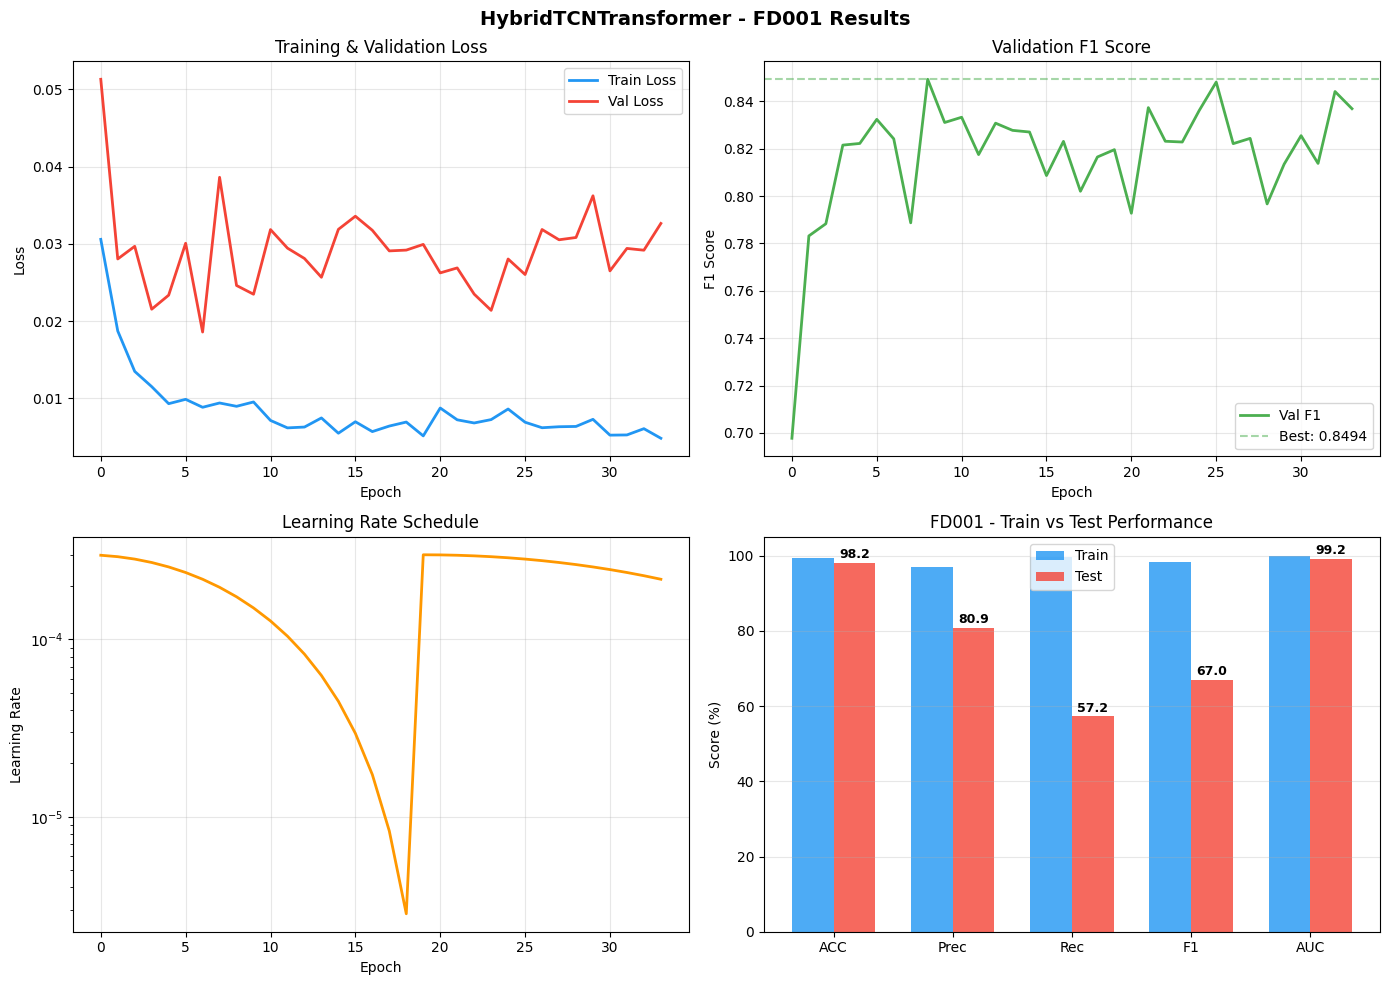

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss curves
ax = axes[0, 0]
ax.plot(history['train_loss'], label='Train Loss', color='#2196F3', linewidth=2)
ax.plot(history['val_loss'], label='Val Loss', color='#F44336', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss')
ax.set_title('Training & Validation Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# F1 curve
ax = axes[0, 1]
ax.plot(history['val_f1'], label='Val F1', color='#4CAF50', linewidth=2)
ax.axhline(y=max(history['val_f1']), color='#4CAF50', linestyle='--', alpha=0.5,
           label=f"Best: {max(history['val_f1']):.4f}")
ax.set_xlabel('Epoch')
ax.set_ylabel('F1 Score')
ax.set_title('Validation F1 Score')
ax.legend()
ax.grid(True, alpha=0.3)

# Learning rate
ax = axes[1, 0]
ax.plot(history['lr'], color='#FF9800', linewidth=2)
ax.set_xlabel('Epoch')
ax.set_ylabel('Learning Rate')
ax.set_title('Learning Rate Schedule')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)

# Train vs Test metrics bar chart
ax = axes[1, 1]
metrics_names = ['ACC', 'Prec', 'Rec', 'F1', 'AUC']
train_vals = [train_results['accuracy'], train_results['precision'],
              train_results['recall'], train_results['f1_score'], train_results['auc_roc']]
test_vals = [test_results['accuracy'], test_results['precision'],
             test_results['recall'], test_results['f1_score'], test_results['auc_roc']]

x = np.arange(len(metrics_names))
width = 0.35
bars1 = ax.bar(x - width/2, train_vals, width, label='Train', color='#2196F3', alpha=0.8)
bars2 = ax.bar(x + width/2, test_vals, width, label='Test', color='#F44336', alpha=0.8)

for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.5,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9,
            fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(metrics_names)
ax.set_ylabel('Score (%)')
ax.set_title('FD001 - Train vs Test Performance')
ax.legend()
ax.set_ylim(0, 105)
ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('HybridTCNTransformer - FD001 Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/hybrid_tcn_transformer_fd001.png', dpi=150, bbox_inches='tight')
plt.show()

## 14. Final Summary

In [ ]:
print("\n" + "=" * 90)
print(" FINAL SUMMARY — HybridTCNTransformer on All C-MAPSS FD Datasets")
print("=" * 90)

header = f"  {'Dataset':<9} {'Thr':>5} | {'Tr-F1':>7} | {'Te-Acc':>7} {'Te-Prec':>8} {'Te-Rec':>8} {'Te-F1':>7} {'Te-AUC':>8} | {'Time(s)':>8}"
print(header)
print(f"  {'-'*86}")

for fd, res in all_fd_results.items():
    tr = res['train']
    te = res['test']
    print(f"  {fd:<9} {res['threshold']:>5.2f} | "
          f"{tr['f1_score']:>6.1f}% | "
          f"{te['accuracy']:>6.1f}% {te['precision']:>7.1f}% "
          f"{te['recall']:>7.1f}% {te['f1_score']:>6.1f}% "
          f"{te['auc_roc']:>7.1f}% | {res['training_time']:>7.1f}s")

print(f"  {'-'*86}")
f1s  = [r['test']['f1_score']  for r in all_fd_results.values()]
recs = [r['test']['recall']    for r in all_fd_results.values()]
aucs = [r['test']['auc_roc']   for r in all_fd_results.values()]
print(f"  {'MEAN':<9}       |         | "
      f"{'':>7} {'':>8} {np.mean(recs):>7.1f}% {np.mean(f1s):>6.1f}% {np.mean(aucs):>7.1f}%")
print("=" * 90)

# --- Per-FD loss & F1 curves ---
n_fds = len(all_fd_results)
fig, axes = plt.subplots(2, n_fds, figsize=(5 * n_fds, 8))

for col, (fd, res) in enumerate(all_fd_results.items()):
    h = res['history']
    ax_loss = axes[0, col]
    ax_f1   = axes[1, col]

    ax_loss.plot(h['train_loss'], label='Train', color='#2196F3', lw=1.5)
    ax_loss.plot(h['val_loss'],   label='Val',   color='#F44336', lw=1.5)
    ax_loss.set_title(f'{fd} — Loss', fontweight='bold')
    ax_loss.set_xlabel('Epoch'); ax_loss.set_ylabel('Loss')
    ax_loss.legend(fontsize=9); ax_loss.grid(True, alpha=0.3)

    ax_f1.plot(h['val_f1'], color='#4CAF50', lw=1.5)
    ax_f1.axhline(max(h['val_f1']), color='#4CAF50', ls='--', alpha=0.5,
                  label=f"Best {max(h['val_f1']):.3f}")
    ax_f1.set_title(f'{fd} — Val F1', fontweight='bold')
    ax_f1.set_xlabel('Epoch'); ax_f1.set_ylabel('F1')
    ax_f1.legend(fontsize=9); ax_f1.grid(True, alpha=0.3)
    ax_f1.set_ylim(0, 1.05)

plt.suptitle('HybridTCNTransformer — Training Curves (All FDs)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/hybrid_tcn_transformer_all_fds.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved: hybrid_tcn_transformer_all_fds.png")


## 15. Save Model

In [ ]:
# Models are saved inside the main loop (cell-28) as:
#   /content/hybrid_tcn_transformer_fd001_model.pth
#   /content/hybrid_tcn_transformer_fd002_model.pth
#   /content/hybrid_tcn_transformer_fd003_model.pth
#   /content/hybrid_tcn_transformer_fd004_model.pth
print("All models saved inside the training loop.")
